In [65]:
from pyspark.sql import SparkSession
from pyspark import SparkConf

conf = SparkConf() \
    .setAppName("WordCount1") \
    .setMaster("local[*]") \
    .set("spark.executor.memory", "2g") \
    .set("spark.driver.memory", "2g") \
    .set("spark.python.worker.memory", "512m") \
    .set("spark.sql.autoBroadcastJoinThreshold", "-1")

spark = SparkSession.builder.config(conf=conf).getOrCreate()

In [66]:
df = spark.read.option("multiLine", True).json("/jokes/stupidstuff.json")

In [67]:
from pyspark.sql.functions import explode, split, lower, col, regexp_replace, count as sql_count

result_df = (
    df.select("id", "body")
    .withColumn("word", explode(split(col("body"), r"\s+")))
    .withColumn("clean_word", lower(regexp_replace(col("word"), r"[^a-zA-Z]", "")))
    .filter(col("clean_word") != "")
    .groupBy("id", "clean_word")
    .agg(sql_count("*").alias("cnt"))
    .orderBy(col("cnt").desc())
    .limit(5)
)

result = result_df.collect()

for row in result:
    print(f"id: {row['id']}, 单词: {row['clean_word']}, 次数: {row['cnt']}")

id: 7, 单词: the, 次数: 40
id: 196, 单词: the, 次数: 33
id: 19, 单词: the, 次数: 32
id: 70, 单词: the, 次数: 30
id: 53, 单词: the, 次数: 30


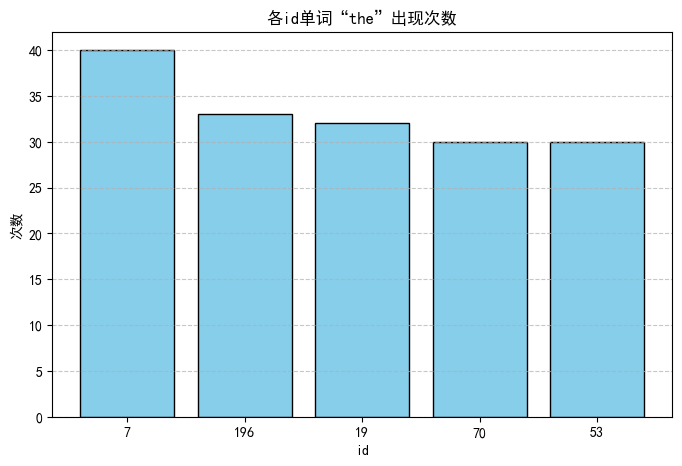

In [69]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

ids = [7, 196, 19, 70, 53]
cnts = [40, 33, 32, 30, 30]

plt.figure(figsize=(8, 5))
plt.bar(range(len(ids)), cnts, color='skyblue', edgecolor='black')
plt.xticks(range(len(ids)), ids)
plt.xlabel('id')
plt.ylabel('次数')
plt.title('各id单词“the”出现次数')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [70]:
with open('Data/english_words.txt') as f:
    words = f.read().split()
with open('Data/Stopwordlist.txt') as f:
    stopwords = set(f.read().splitlines())

counts = {}
for w in words:
    if w not in stopwords:
        counts[w] = counts.get(w, 0) + 1

In [71]:
sorted_items = sorted(counts.items(), key=lambda x: x[1], reverse=True)
top5 = sorted_items[:5]
top20 = sorted_items[:20]

print('最多的5个单词:')
for w, c in top5:
    print(f'{w}: {c}')

最多的5个单词:
2: 1
1080: 1
&c: 1
10-point: 1
10th: 1


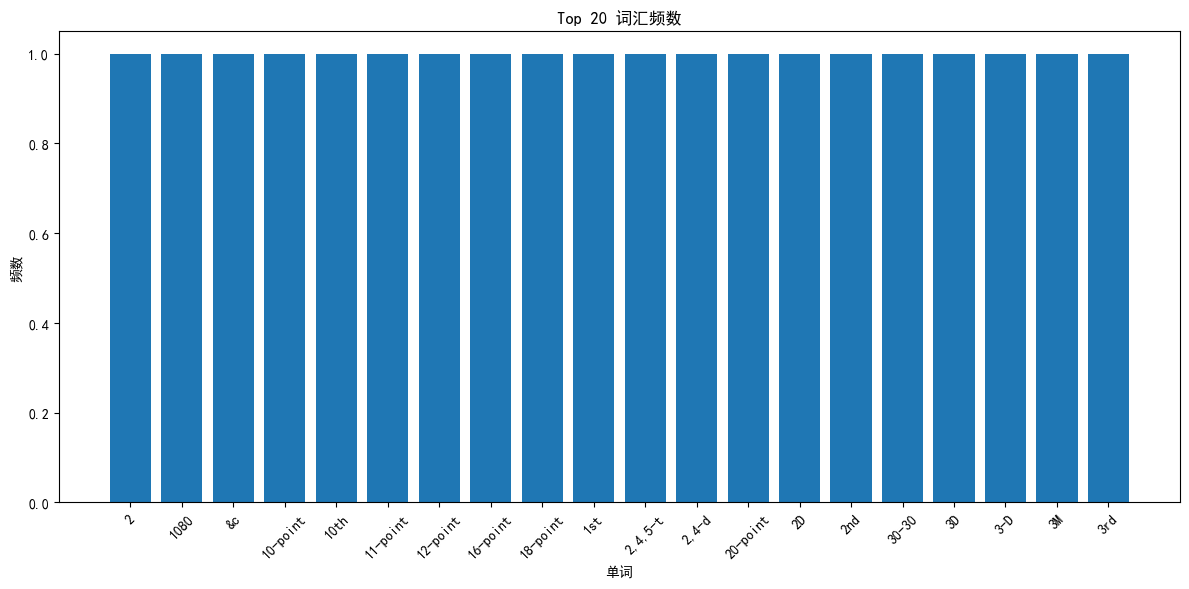

In [72]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

labels = [i[0] for i in top20]
values = [i[1] for i in top20]
plt.figure(figsize=(12,6))
plt.bar(labels, values)
plt.xticks(rotation=45)
plt.xlabel('单词')
plt.ylabel('频数')
plt.title('Top 20 词汇频数')
plt.tight_layout()
plt.show()